In [33]:
# Imports 
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [34]:
# load testing data set and drop null values
df = pd.read_csv("../data/raw/testing_dataset.csv")
df = df.dropna(subset=["text"])

In [35]:
# clean and tokanize
pattern = re.compile(r'[^a-zA-Z\s]+')
noise_pattern = re.compile(r'escapenumber|escapelong', re.IGNORECASE)
stopwords = {'y', 'did', 'i', 'again', "hadn't", 'my', 'over', 'too', 'here', "that'll", 'couldn', 'than', "they've", 'same', "she's", 'they', 'doing', 'if', 'down', "don't", 'out', 'no', 'her', 're', 'such', 't', "i've", 'only', 'was', 'shouldn', "they'd", 'won', 'more', 'needn', 'do', "shouldn't", "wasn't", "aren't", 'aren', 'how', 'shan', 'doesn', 'few', 'll', 'myself', "couldn't", "he'd", 'other', 'wasn', 'his', 'on', 'these', 'both', "didn't", 'you', "you've", 'their', 'what', "you'd", 'being', 'by', 'been', 's', 'ain', 'why', 'where', 'until', 'as', 'off', 'after', 'is', 'be', 'below', 'hasn', 'yours', 'we', 'has', 'own', 've', 'haven', 'whom', 'wouldn', 'hers', "we'd", 'between', 'o', "he's", 'have', 'herself', 'does', 'now', "shan't", 'don', 'in', 'so', 'from', 'a', 'under', 'further', 'those', 'me', 'most', "weren't", 'against', 'its', 'she', 'at', "you'll", 'yourself', "i'll", 'm', 'once', 'mustn', 'while', 'should', 'ours', 'didn', 'then', 'when', 'that', 'were', "it'd", 'which', 'above', 'all', "doesn't", "mustn't", "she'd", "it's", 'before', 'of', 'and', 'weren', "she'll", 'our', 'will', 'isn', "i'm", 'had', 'to', 'the', 'through', 'with', 'there', 'during', 'or', "haven't", 'himself', 'it', 'theirs', "wouldn't", 'each', 'not', 'just', 'this', "we'll", "he'll", "needn't", "we've", 'ourselves', 'about', "isn't", 'your', 'nor', 'because', 'can', 'he', 'am', "i'd", "should've", 'any', 'd', 'some', 'having', 'ma', 'itself', 'into', "we're", "hasn't", "they'll", 'who', 'are', 'but', 'themselves', "mightn't", "it'll", 'very', 'for', 'hadn', "you're", 'him', 'them', 'an', "they're", 'mightn', "won't", 'yourselves', 'up'}
NOISE_WORDS = {"subject", "pm", "org", "com", "http", "www"}

def clean(email: str) -> list[str]:
    email = noise_pattern.sub('', email)
    words = email.lower().split()
    words = [pattern.sub('', w) for w in words]
    words = [
        w for w in words
        if w and len(w) > 1 and w not in stopwords and w not in NOISE_WORDS
    ]
    return words

In [36]:
# Prediction
def load_model(path="../models/modelv1.json"):
    with open(path, "r") as f:
        model = json.load(f)
    vocab = model["vocab"]
    log_prior_s, log_prior_h = np.array(model["log_priors"])
    log_likelihoods = np.array(model["log_likelihoods"])
    return vocab, log_prior_s, log_prior_h, log_likelihoods

def predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods):
    cleaned = clean(email)
    log_post_spam = log_prior_s
    log_post_ham = log_prior_h

    for word in cleaned:
        index = vocab.get(word)
        if index is None:
            continue
        log_post_spam += log_likelihoods[0][index]
        log_post_ham += log_likelihoods[1][index]

    return "spam" if log_post_spam > log_post_ham else "ham"

In [37]:
vocab, log_prior_s, log_prior_h, log_likelihoods = load_model()

In [38]:
# compute the true positives, true negatives, false positives and false negavitves 
# negative is ham and positive is spam 
# tp are emails classified as spam and are spam 
# tn are emails classified as ham and are ham 
# fp are emails classified as spam but are ham 
# fn are emails classified as ham but are spam 

def confusion(model_path, test_df): 
    vocab, log_prior_s, log_prior_h, log_likelihoods = load_model(model_path)
    tp, tn, fp, fn = 0, 0, 0, 0

    for index, row in test_df.iterrows():
        label = row["label"].lower()
        email = row["text"]

        prediction = predict(email, vocab, log_prior_s, log_prior_h, log_likelihoods)

        match (label, prediction):
            case ("spam", "spam"):
                tp += 1
            case ("ham", "ham"):
                tn += 1
            case ("ham", "spam"):
                fp += 1
            case ("spam", "ham"):
                fn += 1
                
    confusion_matrix = np.vstack([[tp, fn], [fp, tn]])
    
    return confusion_matrix, tp, tn, fp, fn 

In [39]:
# compute precision, recall and F1 for each model 
model_performance = []

models = ["../models/modelv1.json", "../models/modelv2.json", "../models/modelv3.json", "../models/modelv4.json"]

for path in models:
    confusion_matrix, tp, tn, fp, fn = confusion(path, df)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1 = 2*((precision * recall) / (precision + recall))

    model_performance.append({
        "Model": path,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


In [40]:
results_df = pd.DataFrame(model_performance)
results_df

,Model,Precision,Recall,F1-score
0,../models/modelv1.json,0.976039,0.951481,0.963604
1,../models/modelv2.json,0.975870,0.951567,0.963565
2,../models/modelv3.json,0.978570,0.941091,0.959464
3,../models/modelv4.json,0.981686,0.929841,0.955061


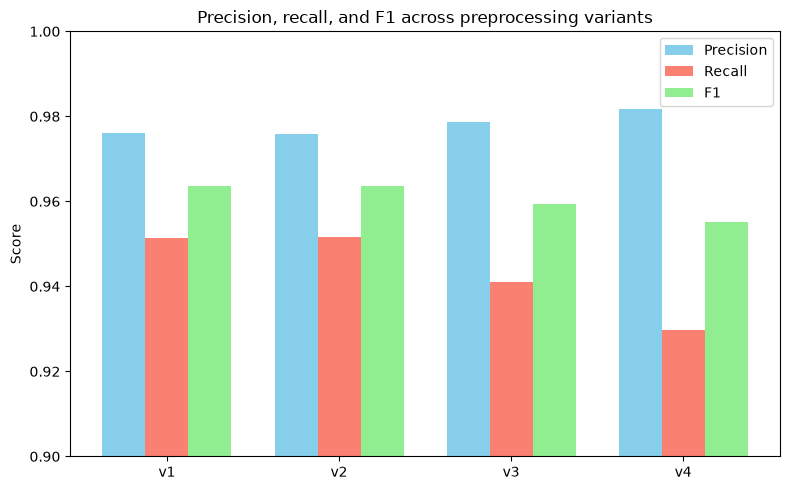

In [41]:
x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, results_df["Precision"], width, label="Precision", color="skyblue")
ax.bar(x, results_df["Recall"], width, label="Recall", color="salmon")
ax.bar(x + width, results_df["F1-score"], width, label="F1", color="lightgreen")

ax.set_xticks(x)
ax.set_xticklabels(["v1", "v2", "v3", "v4"])
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Score")
ax.set_title("Precision, recall, and F1 across preprocessing variants")
ax.legend()

plt.tight_layout()
plt.show()